In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

PROCESSED = Path("../data/processed")
REPORTS   = Path("../reports")
OUTPUTS   = Path("../data/processed")
REPORTS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 100

print("Libraries loaded")

Libraries loaded


In [2]:
df_nav   = pd.read_csv(PROCESSED / "clean_nav_history.csv", parse_dates=["date"])
df_fund  = pd.read_csv(PROCESSED / "clean_fund_master.csv")
df_bench = pd.read_csv(PROCESSED / "clean_benchmark_indices.csv", parse_dates=["date"])
df_perf  = pd.read_csv(PROCESSED / "clean_scheme_performance.csv")

print("Datasets loaded!")
print(f"nav_history    : {df_nav.shape}")
print(f"fund_master    : {df_fund.shape}")
print(f"benchmark      : {df_bench.shape}")
print(f"performance    : {df_perf.shape}")
print(f"\nNAV columns    : {df_nav.columns.tolist()}")
print(f"Bench columns  : {df_bench.columns.tolist()}")

Datasets loaded!
nav_history    : (46000, 4)
fund_master    : (40, 15)
benchmark      : (8050, 3)
performance    : (40, 19)

NAV columns    : ['amfi_code', 'date', 'nav', 'daily_return_pct']
Bench columns  : ['date', 'index_name', 'close_value']


Daily Return Statistics:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Max return  : 0.0647 (6.47%)
Min return  : -0.0581 (-5.81%)
Mean return : 0.000631 (0.0631%)


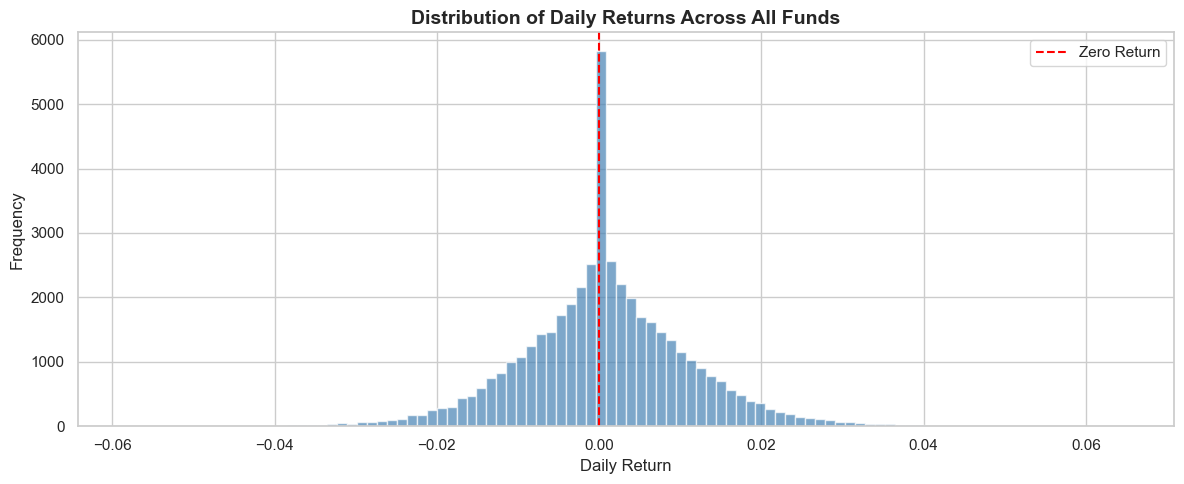

returns_computed.csv saved!


In [3]:
df_nav = df_nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

df_nav["daily_return"] = (df_nav.groupby("amfi_code")["nav"]
                          .pct_change())

df_returns = df_nav.dropna(subset=["daily_return"]).copy()

print("Daily Return Statistics:")
print(df_returns["daily_return"].describe())
print(f"\nMax return  : {df_returns['daily_return'].max():.4f} ({df_returns['daily_return'].max()*100:.2f}%)")
print(f"Min return  : {df_returns['daily_return'].min():.4f} ({df_returns['daily_return'].min()*100:.2f}%)")
print(f"Mean return : {df_returns['daily_return'].mean():.6f} ({df_returns['daily_return'].mean()*100:.4f}%)")

plt.figure(figsize=(12, 5))
plt.hist(df_returns["daily_return"], bins=100, color="steelblue", edgecolor="white", alpha=0.7)
plt.title("Distribution of Daily Returns Across All Funds", fontsize=14, fontweight="bold")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.axvline(x=0, color="red", linestyle="--", label="Zero Return")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / "chart_daily_returns_dist.png", dpi=150, bbox_inches="tight")
plt.show()

df_returns.to_csv(OUTPUTS / "returns_computed.csv", index=False)
print("returns_computed.csv saved!")

In [4]:
def compute_cagr(group, years):
    group = group.sort_values("date")
    end_date   = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)
    data = group[group["date"] >= start_date]
    if len(data) < 2:
        return np.nan
    nav_start = data.iloc[0]["nav"]
    nav_end   = data.iloc[-1]["nav"]
    n = (data.iloc[-1]["date"] - data.iloc[0]["date"]).days / 365.25
    if n <= 0 or nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / n) - 1

cagr_results = []
for code, group in df_nav.groupby("amfi_code"):
    cagr_results.append({
        "amfi_code"    : code,
        "cagr_1yr_pct" : round(compute_cagr(group, 1) * 100, 2),
        "cagr_3yr_pct" : round(compute_cagr(group, 3) * 100, 2),
        "cagr_5yr_pct" : round(compute_cagr(group, 5) * 100, 2),
    })

df_cagr = pd.DataFrame(cagr_results)
df_cagr = df_cagr.merge(df_fund[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code", how="left")
df_cagr = df_cagr.sort_values("cagr_3yr_pct", ascending=False).reset_index(drop=True)

print("CAGR Comparison Table:")
print(df_cagr[["scheme_name", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct"]].to_string(index=False))

df_cagr.to_csv(OUTPUTS / "cagr_report.csv", index=False)
print("\ncagr_report.csv saved!")

CAGR Comparison Table:
                                          scheme_name  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
                  Axis Midcap Fund - Regular - Growth         22.28         35.10         28.21
        Mirae Asset Large Cap Fund - Regular - Growth         20.38         33.99         30.97
            ICICI Pru Bluechip Fund - Direct - Growth         13.07         32.48         23.30
   HDFC Mid-Cap Opportunities Fund - Regular - Growth         53.28         32.43         30.12
             ICICI Pru Midcap Fund - Regular - Growth         29.63         31.77         32.83
            SBI Bluechip Fund - Regular Plan - Growth         60.49         30.45         25.80
               Kotak Flexicap Fund - Regular - Growth         26.68         29.58         30.91
        Mirae Asset Tax Saver Fund - Regular - Growth         39.78         29.17         31.95
        ABSL Frontline Equity Fund - Regular - Growth         47.96         28.96         23.54
                D

Top 10 Funds by Sharpe Ratio:
                                       scheme_name  sharpe_ratio  volatility
     Mirae Asset Large Cap Fund - Regular - Growth        1.4483      0.8941
            Kotak Flexicap Fund - Regular - Growth        1.3067      1.0008
     Mirae Asset Tax Saver Fund - Regular - Growth        1.2349      1.1134
         SBI Bluechip Fund - Regular Plan - Growth        1.2083      0.8656
          ICICI Pru Midcap Fund - Regular - Growth        1.1801      1.2152
                DSP Midcap Fund - Regular - Growth        1.1321      1.1179
HDFC Mid-Cap Opportunities Fund - Regular - Growth        1.0937      1.1929
    Nippon India Large Cap Fund - Regular - Growth        1.0817      0.8913
     ABSL Frontline Equity Fund - Regular - Growth        1.0272      0.9177
         ICICI Pru Bluechip Fund - Direct - Growth        1.0265      0.9048

sharpe_values.csv saved!


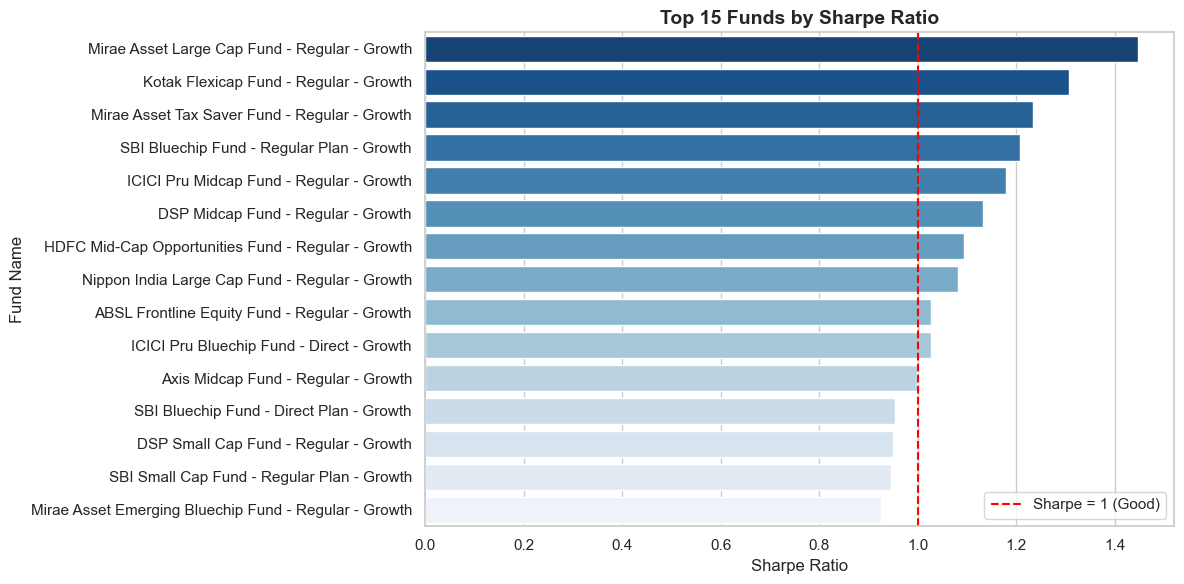

In [5]:
RF_ANNUAL = 0.065        
RF_DAILY  = RF_ANNUAL / 252  

sharpe_results = []
for code, group in df_returns.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    if len(returns) < 30:
        continue
    excess_return = returns - RF_DAILY
    sharpe = (excess_return.mean() / returns.std()) * np.sqrt(252)
    sharpe_results.append({
        "amfi_code"   : code,
        "sharpe_ratio": round(sharpe, 4),
        "avg_daily_return": round(returns.mean() * 100, 4),
        "volatility"  : round(returns.std() * 100, 4),
    })

df_sharpe = pd.DataFrame(sharpe_results)
df_sharpe = df_sharpe.merge(
    df_fund[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code", how="left"
)
df_sharpe = df_sharpe.sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)

print("Top 10 Funds by Sharpe Ratio:")
print(df_sharpe[["scheme_name", "sharpe_ratio", "volatility"]].head(10).to_string(index=False))

df_sharpe.to_csv(OUTPUTS / "sharpe_values.csv", index=False)
print("\nsharpe_values.csv saved!")

plt.figure(figsize=(12, 6))
top15 = df_sharpe.head(15)
sns.barplot(data=top15, x="sharpe_ratio", y="scheme_name", palette="Blues_r")
plt.axvline(x=1, color="red", linestyle="--", label="Sharpe = 1 (Good)")
plt.title("Top 15 Funds by Sharpe Ratio", fontsize=14, fontweight="bold")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Fund Name")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / "chart_sharpe_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
sortino_results = []
for code, group in df_returns.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    if len(returns) < 30:
        continue

    excess_return  = returns - RF_DAILY
    downside       = returns[returns < 0]
    downside_std   = downside.std() if len(downside) > 1 else np.nan

    if pd.isna(downside_std) or downside_std == 0:
        continue

    sortino = (excess_return.mean() / downside_std) * np.sqrt(252)
    sortino_results.append({
        "amfi_code"    : code,
        "sortino_ratio": round(sortino, 4),
        "downside_std" : round(downside_std * 100, 4),
    })

df_sortino = pd.DataFrame(sortino_results)
df_sortino = df_sortino.merge(
    df_fund[["amfi_code", "scheme_name"]],
    on="amfi_code", how="left"
)
df_sortino = df_sortino.sort_values("sortino_ratio", ascending=False).reset_index(drop=True)

print("Top 10 Funds by Sortino Ratio:")
print(df_sortino[["scheme_name", "sortino_ratio", "downside_std"]].head(10).to_string(index=False))

df_sortino.to_csv(OUTPUTS / "sortino_values.csv", index=False)
print("\nsortino_values.csv saved!")

Top 10 Funds by Sortino Ratio:
                                       scheme_name  sortino_ratio  downside_std
     Mirae Asset Large Cap Fund - Regular - Growth         2.3856        0.5428
            Kotak Flexicap Fund - Regular - Growth         2.3643        0.5531
     Mirae Asset Tax Saver Fund - Regular - Growth         2.1469        0.6404
         SBI Bluechip Fund - Regular Plan - Growth         2.1403        0.4887
          ICICI Pru Midcap Fund - Regular - Growth         2.0294        0.7067
                DSP Midcap Fund - Regular - Growth         1.8751        0.6750
    Nippon India Large Cap Fund - Regular - Growth         1.8501        0.5211
HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.8291        0.7133
         ICICI Pru Bluechip Fund - Direct - Growth         1.8053        0.5145
     ABSL Frontline Equity Fund - Regular - Growth         1.7996        0.5238

sortino_values.csv saved!


In [7]:
print("Benchmark columns:", df_bench.columns.tolist())
print(df_bench.head(3))

Benchmark columns: ['date', 'index_name', 'close_value']
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05


In [8]:
df_nifty = df_bench[df_bench["index_name"] == "NIFTY50"].copy()

df_nifty = df_nifty.sort_values("date")

df_nifty["bench_return"] = df_nifty["close_value"].pct_change()

df_nifty = df_nifty[["date", "bench_return"]].dropna()

print(df_nifty.head())

from scipy import stats

alpha_beta_results = []

for code, group in df_returns.groupby("amfi_code"):

    merged = group[["date", "daily_return"]].merge(
        df_nifty,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged["bench_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": code,
        "beta": round(slope, 4),
        "alpha": round(intercept * 252 * 100, 4),
        "r_squared": round(r_value ** 2, 4)
    })

df_alpha_beta = pd.DataFrame(alpha_beta_results)

df_alpha_beta = df_alpha_beta.merge(
    df_fund[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

df_alpha_beta = df_alpha_beta.sort_values(
    "alpha",
    ascending=False
).reset_index(drop=True)

print("\nTop 10 Funds by Alpha:")
print(
    df_alpha_beta[
        ["scheme_name", "alpha", "beta", "r_squared"]
    ].head(10).to_string(index=False)
)

df_alpha_beta.to_csv(
    OUTPUTS / "alpha_beta.csv",
    index=False
)

print("\nalpha_beta.csv saved!")

        date  bench_return
1 2022-01-04      0.011253
2 2022-01-05      0.008220
3 2022-01-06      0.002437
4 2022-01-07     -0.006676
5 2022-01-10      0.020592

Top 10 Funds by Alpha:
                                       scheme_name   alpha    beta  r_squared
        SBI Small Cap Fund - Regular Plan - Growth 30.1114  0.0743     0.0014
             DSP Small Cap Fund - Regular - Growth 29.8179  0.1326     0.0047
          ICICI Pru Midcap Fund - Regular - Growth 29.3014 -0.0174     0.0001
     Mirae Asset Tax Saver Fund - Regular - Growth 28.3473 -0.0102     0.0001
            Kotak Flexicap Fund - Regular - Growth 27.2784 -0.0087     0.0001
HDFC Mid-Cap Opportunities Fund - Regular - Growth 27.2343 -0.0112     0.0001
     Mirae Asset Large Cap Fund - Regular - Growth 27.1150 -0.0281     0.0007
                DSP Midcap Fund - Regular - Growth 26.5836  0.0035     0.0000
               Axis Midcap Fund - Regular - Growth 25.9971 -0.0599     0.0016
         SBI Bluechip Fund - Regul

In [9]:
drawdown_results = []
for code, group in df_nav.groupby("amfi_code"):
    group = group.sort_values("date")
    nav   = group["nav"].values
    dates = group["date"].values

    running_max = np.maximum.accumulate(nav)
    drawdown    = nav / running_max - 1
    max_dd      = drawdown.min()
    max_dd_idx  = drawdown.argmin()

    peak_idx = np.argmax(nav[:max_dd_idx + 1])

    drawdown_results.append({
        "amfi_code"       : code,
        "max_drawdown_pct": round(max_dd * 100, 2),
        "peak_date"       : dates[peak_idx],
        "trough_date"     : dates[max_dd_idx],
    })

df_drawdown = pd.DataFrame(drawdown_results)
df_drawdown = df_drawdown.merge(
    df_fund[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code", how="left"
)
df_drawdown = df_drawdown.sort_values("max_drawdown_pct").reset_index(drop=True)

print("Worst 10 Funds by Max Drawdown:")
print(df_drawdown[["scheme_name", "max_drawdown_pct", "peak_date", "trough_date"]].head(10).to_string(index=False))

df_drawdown.to_csv(OUTPUTS / "max_drawdown.csv", index=False)
print("\nmax_drawdown.csv saved!")

Worst 10 Funds by Max Drawdown:
                                   scheme_name  max_drawdown_pct  peak_date trough_date
     SBI Small Cap Fund - Direct Plan - Growth            -52.57 2023-01-17  2025-10-28
        Axis Small Cap Fund - Regular - Growth            -51.68 2025-05-22  2026-05-11
        ABSL Small Cap Fund - Regular - Growth            -35.45 2024-11-21  2026-05-11
         DSP Small Cap Fund - Regular - Growth            -31.17 2024-05-03  2025-01-03
    SBI Small Cap Fund - Regular Plan - Growth            -28.71 2024-08-28  2025-05-14
           UTI Mid Cap Fund - Regular - Growth            -28.00 2025-01-07  2026-04-27
     HDFC Top 100 Fund - Regular Plan - Growth            -24.73 2022-03-30  2022-09-15
 Kotak Emerging Equity Fund - Regular - Growth            -24.00 2023-11-09  2024-10-17
Nippon India Small Cap Fund - Regular - Growth            -23.34 2025-04-09  2026-02-20
          Axis Bluechip Fund - Direct - Growth            -21.75 2022-02-24  2023-05-22


Fund Scorecard — Top 10:
 fund_rank                                        scheme_name  composite_score  cagr_3yr_pct  sharpe_ratio   alpha
         1           ICICI Pru Midcap Fund - Regular - Growth          84.5000         31.77        1.1801 29.3014
         2                Axis Midcap Fund - Regular - Growth          80.7500         35.10        0.9982 25.9971
         3 HDFC Mid-Cap Opportunities Fund - Regular - Growth          80.5000         32.43        1.0937 27.2343
         4      Mirae Asset Large Cap Fund - Regular - Growth          80.0000         33.99        1.4483 27.1150
         5             Kotak Flexicap Fund - Regular - Growth          78.2500         29.58        1.3067 27.2784
         6          ICICI Pru Bluechip Fund - Direct - Growth          75.7500         32.48        1.0265 21.2094
         7         SBI Small Cap Fund - Regular Plan - Growth          75.1250         26.66        0.9453 30.1114
         8              DSP Small Cap Fund - Regular - 

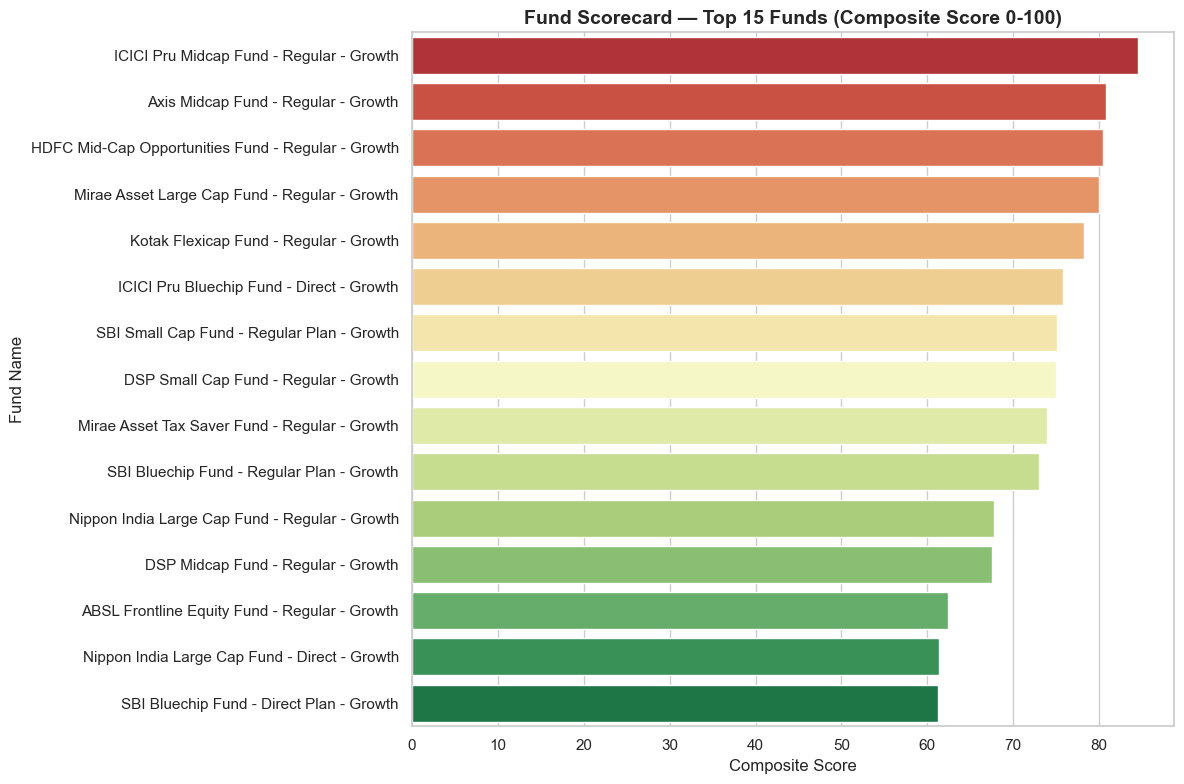

In [10]:
df_score = df_cagr[["amfi_code", "cagr_3yr_pct"]].copy()
df_score = df_score.merge(df_sharpe[["amfi_code", "sharpe_ratio"]], on="amfi_code", how="left")
df_score = df_score.merge(df_alpha_beta[["amfi_code", "alpha"]], on="amfi_code", how="left")
df_score = df_score.merge(df_drawdown[["amfi_code", "max_drawdown_pct"]], on="amfi_code", how="left")
df_score = df_score.merge(df_fund[["amfi_code", "scheme_name", "fund_house", "expense_ratio_pct"]], on="amfi_code", how="left")

df_score["rank_3yr"]     = df_score["cagr_3yr_pct"].rank(ascending=True)
df_score["rank_sharpe"]  = df_score["sharpe_ratio"].rank(ascending=True)
df_score["rank_alpha"]   = df_score["alpha"].rank(ascending=True)
df_score["rank_expense"] = df_score["expense_ratio_pct"].rank(ascending=False)
df_score["rank_maxdd"]   = df_score["max_drawdown_pct"].rank(ascending=False)

for col in ["rank_3yr", "rank_sharpe", "rank_alpha", "rank_expense", "rank_maxdd"]:
    df_score[col] = (df_score[col] / df_score[col].max()) * 100

df_score["composite_score"] = (
    0.30 * df_score["rank_3yr"]     +
    0.25 * df_score["rank_sharpe"]  +
    0.20 * df_score["rank_alpha"]   +
    0.15 * df_score["rank_expense"] +
    0.10 * df_score["rank_maxdd"]
)

df_score = df_score.sort_values("composite_score", ascending=False).reset_index(drop=True)
df_score["fund_rank"] = df_score.index + 1

print("Fund Scorecard — Top 10:")
print(df_score[["fund_rank", "scheme_name", "composite_score",
                "cagr_3yr_pct", "sharpe_ratio", "alpha"]].head(10).to_string(index=False))

df_score.to_csv(OUTPUTS / "fund_scorecard.csv", index=False)
print("\nfund_scorecard.csv saved!")

plt.figure(figsize=(12, 8))
top15 = df_score.head(15)
sns.barplot(data=top15, x="composite_score", y="scheme_name", palette="RdYlGn")
plt.title("Fund Scorecard — Top 15 Funds (Composite Score 0-100)",
          fontsize=14, fontweight="bold")
plt.xlabel("Composite Score")
plt.ylabel("Fund Name")
plt.tight_layout()
plt.savefig(REPORTS / "chart_fund_scorecard.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
print("Benchmark columns:", df_bench.columns.tolist())

Benchmark columns: ['date', 'index_name', 'close_value']


NIFTY50 rows: 1150
NIFTY100 rows: 1150


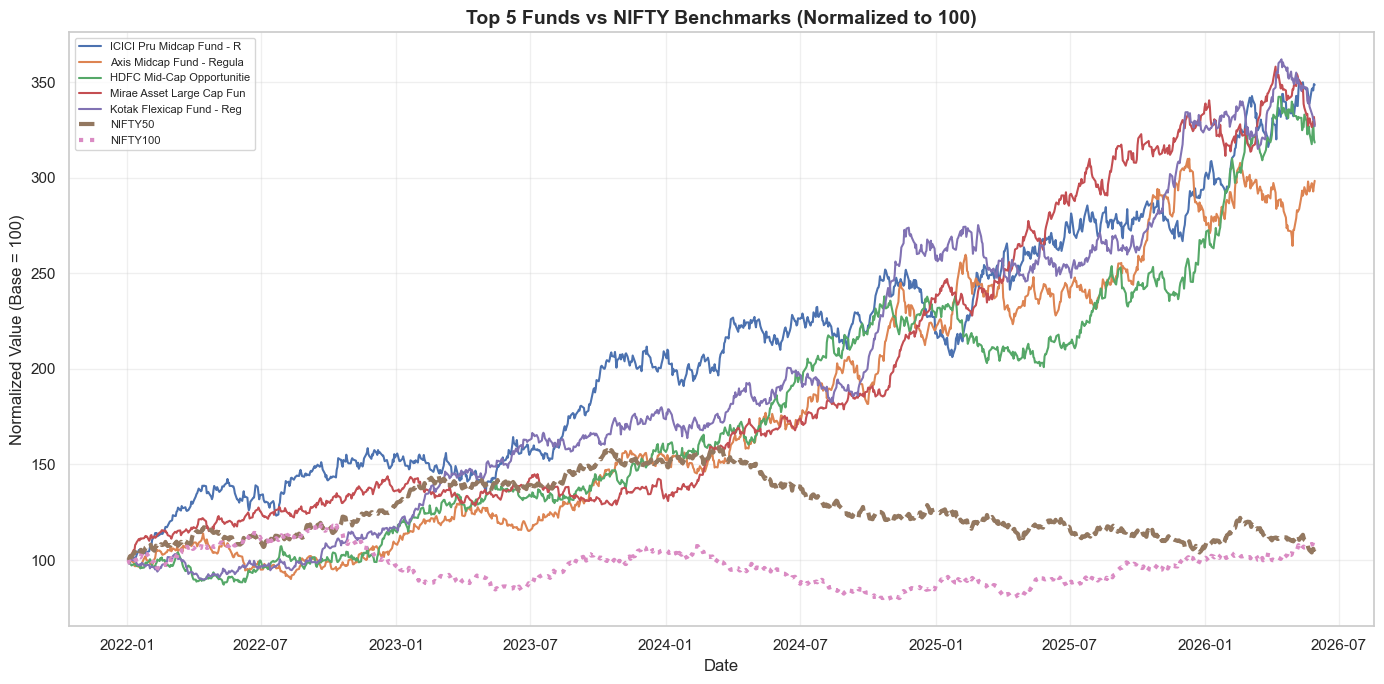


Tracking Error vs NIFTY50
ICICI Pru Midcap Fund - Regular - G : 23.31%
Axis Midcap Fund - Regular - Growth : 23.71%
HDFC Mid-Cap Opportunities Fund - R : 22.98%
Mirae Asset Large Cap Fund - Regula : 19.40%
Kotak Flexicap Fund - Regular - Gro : 20.51%

Benchmark comparison chart saved!


In [12]:

top5_codes = df_score.head(5)["amfi_code"].tolist()
top5_names = (
    df_score.head(5)
    .set_index("amfi_code")["scheme_name"]
    .to_dict()
)

nifty50 = df_bench[df_bench["index_name"] == "NIFTY50"].copy()
nifty100 = df_bench[df_bench["index_name"] == "NIFTY100"].copy()

print("NIFTY50 rows:", len(nifty50))
print("NIFTY100 rows:", len(nifty100))

fig, ax = plt.subplots(figsize=(14, 7))

for code in top5_codes:

    fund_data = (
        df_nav[df_nav["amfi_code"] == code]
        .sort_values("date")
    )

    fund_data = fund_data[
        fund_data["date"] >= "2022-01-01"
    ]

    if len(fund_data) == 0:
        continue

    normalized = (
        fund_data["nav"]
        / fund_data["nav"].iloc[0]
        * 100
    )

    ax.plot(
        fund_data["date"],
        normalized,
        label=top5_names.get(code, str(code))[:25],
        linewidth=1.5
    )

if len(nifty50) > 0:

    nifty50 = nifty50.sort_values("date")

    nifty50 = nifty50[
        nifty50["date"] >= "2022-01-01"
    ]

    normalized_50 = (
        nifty50["close_value"]
        / nifty50["close_value"].iloc[0]
        * 100
    )

    ax.plot(
        nifty50["date"],
        normalized_50,
        label="NIFTY50",
        linewidth=3,
        linestyle="--"
    )

if len(nifty100) > 0:

    nifty100 = nifty100.sort_values("date")

    nifty100 = nifty100[
        nifty100["date"] >= "2022-01-01"
    ]

    normalized_100 = (
        nifty100["close_value"]
        / nifty100["close_value"].iloc[0]
        * 100
    )

    ax.plot(
        nifty100["date"],
        normalized_100,
        label="NIFTY100",
        linewidth=3,
        linestyle=":"
    )

ax.set_title(
    "Top 5 Funds vs NIFTY Benchmarks (Normalized to 100)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Normalized Value (Base = 100)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig(
    REPORTS / "chart_benchmark_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nTracking Error vs NIFTY50")

bench_ret = nifty50[["date", "close_value"]].copy()
bench_ret["bench_return"] = bench_ret["close_value"].pct_change()

for code in top5_codes:

    fund_ret = df_returns[
        df_returns["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = fund_ret.merge(
        bench_ret[["date", "bench_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 10:
        continue

    tracking_error = (
        (merged["daily_return"] - merged["bench_return"]).std()
        * np.sqrt(252)
        * 100
    )

    fund_name = top5_names.get(code, str(code))

    print(
        f"{fund_name[:35]:<35} : "
        f"{tracking_error:.2f}%"
    )

print("\nBenchmark comparison chart saved!")

In [15]:
print("Summary")
for f in ["returns_computed.csv", "cagr_report.csv", "sharpe_values.csv",
          "sortino_values.csv", "alpha_beta.csv", "max_drawdown.csv",
          "fund_scorecard.csv"]:
    path = OUTPUTS / f
    if path.exists():
        df = pd.read_csv(path)
        print(f"  {f:<30} : {len(df):,} rows")

print("\nCharts saved:")
charts = list(REPORTS.glob("chart_*.png"))
for c in sorted(charts):
    print(f"  {c.name}")


Summary
  returns_computed.csv           : 45,960 rows
  cagr_report.csv                : 40 rows
  sharpe_values.csv              : 40 rows
  sortino_values.csv             : 40 rows
  alpha_beta.csv                 : 40 rows
  max_drawdown.csv               : 40 rows
  fund_scorecard.csv             : 40 rows

Charts saved:
  chart_benchmark_comparison.png
  chart_daily_returns_dist.png
  chart_fund_scorecard.png
  chart_sharpe_ratio.png
